# Visual Analytics Coursework

### Data preparation

In [3]:
import pandas as pd

#### Qualification by Sex

In [5]:
# Map 2021 sheet names to match 2011 format
sheet_name_mapping = {
    "Male": "Males",
    "Female": "Females"
}

def load_all_qualification_sheets(file_path, year, ref_columns=None, skiprows=6, sheet_map=None):
    xls = pd.ExcelFile(file_path)
    all_data = []

    for sheet in xls.sheet_names:
        try:
            df_raw = pd.read_excel(xls, sheet_name=sheet, skiprows=skiprows)
            columns = df_raw.iloc[1].tolist()
            df = df_raw.iloc[2:].copy()
            df.columns = columns

            # Rename first two cols
            rename_map = {
                columns[0]: "Geography Name",
                columns[1]: "Geography Code"
            }
            df.rename(columns=rename_map, inplace=True)

            # Align columns if reference is given (based on 2011)
            if ref_columns:
                new_cols = ["Geography Name", "Geography Code"] + ref_columns[2:]
                df = df.reindex(columns=new_cols)

            # Normalize sheet name
            sheet_label = sheet_map.get(sheet, sheet) if sheet_map else sheet
            df["Year"] = year
            df["Sheet"] = sheet_label

            all_data.append(df)
        except Exception as e:
            print(f"Skipped sheet: {sheet} due to error: {e}")

    return pd.concat(all_data, ignore_index=True)

# Load 2011 and store reference column order
qual_2011 = load_all_qualification_sheets("LC5107EW - Highest level of qualification by sex.xlsx", year=2011)
ref_columns = qual_2011.columns.tolist()

# Load 2021 with normalized sheet names
qual_2021 = load_all_qualification_sheets(
    "RM055 - Highest level of qualification by sex.xlsx",
    year=2021,
    ref_columns=ref_columns,
    sheet_map=sheet_name_mapping
)

# Combine and export
qual_both = pd.concat([qual_2011, qual_2021], ignore_index=True)
qual_both.to_csv("qualification_by_sex_combined_full.csv", index=False)

#### Occupation by Sex

In [7]:
import pandas as pd
import re

# Normalize column titles
def clean_column_names(cols):
    return [re.sub(r"^\d+\.\s*", "", str(col)).strip() for col in cols]

# Map 2021 sheets to match 2011 sheet names
sheet_name_mapping = {
    "Male": "Males",
    "Female": "Females"
}

def load_occupation_sheets(file_path, year, ref_columns=None, skiprows=6, sheet_map=None):
    xls = pd.ExcelFile(file_path)
    all_data = []

    for sheet in xls.sheet_names:
        try:
            df_raw = pd.read_excel(xls, sheet_name=sheet, skiprows=skiprows)
            columns = df_raw.iloc[1].tolist()
            df = df_raw.iloc[2:].copy()
            df.columns = columns

            # Rename Geography columns
            df.rename(columns={
                columns[0]: "Geography Name",
                columns[1]: "Geography Code"
            }, inplace=True)

            # Clean occupation titles
            df.columns = clean_column_names(df.columns)

            # Reorder to match 2011 if reference is passed
            if ref_columns:
                df = df.reindex(columns=ref_columns)

            # Normalize sheet name using mapping
            sheet_label = sheet_map.get(sheet, sheet) if sheet_map else sheet
            df["Year"] = year
            df["Sheet"] = sheet_label

            all_data.append(df)
        except Exception as e:
            print(f"Skipped sheet: {sheet} due to error: {e}")

    return pd.concat(all_data, ignore_index=True)

# Load 2011 first to capture structure
occ_2011 = load_occupation_sheets("LC6120EW - Occupation by sex.xlsx", year=2011)
ref_columns = occ_2011.columns.tolist()

# Load 2021 using mapped sheet names and ref structure
occ_2021 = load_occupation_sheets(
    "RM107 - Occupation by sex.xlsx",
    year=2021,
    ref_columns=ref_columns,
    sheet_map=sheet_name_mapping
)

# Combine and save
occ_sex_combined = pd.concat([occ_2011, occ_2021], ignore_index=True)
occ_sex_combined.to_csv("occupation_by_sex_combined_full.csv", index=False)

C:\Users\snand\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\snand\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


#### Occupation by Age

In [9]:
import pandas as pd
import re

# Clean column names to remove leading numbers and whitespace
def clean_column_names(cols):
    return [re.sub(r"^\d+\.\s*", "", str(col)).strip() for col in cols]

# Mapping 2021 sheet names to match 2011
sheet_name_mapping = {
    "Aged 16 to 24 years": "Age 16 to 24",
    "Aged 25 to 34 years": "Age 25 to 34",
    "Aged 35 to 49 years": "Age 35 to 49",
    "Aged 50 to 64 years": "Age 50 to 64",
    "Aged 65 years and over": "Age 65 and over",
    "Total": "All categories  Age 16 and over"
}

def load_occupation_by_age_sheets(file_path, year, ref_columns=None, skiprows=6, sheet_map=None):
    xls = pd.ExcelFile(file_path)
    all_data = []

    for sheet in xls.sheet_names:
        try:
            df_raw = pd.read_excel(xls, sheet_name=sheet, skiprows=skiprows)
            columns = df_raw.iloc[1].tolist()
            df = df_raw.iloc[2:].copy()
            df.columns = columns

            # Rename standard geography columns
            df.rename(columns={
                columns[0]: "Geography Name",
                columns[1]: "Geography Code"
            }, inplace=True)

            # Clean column names BEFORE trying to reindex
            df.columns = clean_column_names(df.columns)

            # Standardize 2021 structure to match 2011 after cleaning
            if ref_columns:
                df = df.reindex(columns=ref_columns)

            # Normalize sheet names
            sheet_label = sheet_map.get(sheet, sheet) if sheet_map else sheet
            df["Year"] = year
            df["Sheet"] = sheet_label

            all_data.append(df)
        except Exception as e:
            print(f"Skipped sheet: {sheet} due to error: {e}")

    return pd.concat(all_data, ignore_index=True)

# Step 1: Load 2011 to get clean reference columns
occ_age_2011 = load_occupation_by_age_sheets("LC6112EW - Occupation by age.xlsx", year=2011)
ref_columns = occ_age_2011.columns.tolist()

# Step 2: Load 2021 using the mapped sheet names and reordered logic
occ_age_2021 = load_occupation_by_age_sheets(
    "RM102 - Occupation by age.xlsx",
    year=2021,
    ref_columns=ref_columns,
    sheet_map=sheet_name_mapping
)

# Step 3: Combine and save
occ_age_combined = pd.concat([occ_age_2011, occ_age_2021], ignore_index=True)
occ_age_combined.to_csv("occupation_by_age_combined_full.csv", index=False)

C:\Users\snand\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\snand\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


#### Industry by Sex

In [11]:
import pandas as pd
import re

# Clean column names
def clean_column_names(cols):
    return [re.sub(r"^\d+\.\s*", "", str(col)).strip() for col in cols]

# Standardized industry column mapping
column_mapping_industry = {
    'All categories: Industry': 'All',
    'Total': 'All',
    'A, B, D, E Agriculture, energy and water': 'Agriculture_Energy',
    'C Manufacturing': 'Manufacturing',
    'F Construction': 'Construction',
    'G, I Distribution, hotels and restaurants': 'Distribution_Hotels',
    'H, J Transport and communication': 'Transport_Communication',
    'K, L, M, N Financial, Real Estate, Professional and Administrative activities': 'Finance_RealEstate_ProfTech',
    'K, L, M, N Financial, real estate, professional and administrative activities': 'Finance_RealEstate_ProfTech',
    'O, P, Q Public administration, education and health': 'Public_Admin_Education_Health',
    'R, S, T, U Other': 'Other_Industries'
}

# Map 2021 sheet names to match 2011 format
sheet_name_mapping = {
    "Male": "Males",
    "Female": "Females"
}

def load_industry_by_sex_sheets(file_path, year, ref_columns=None, skiprows=6, sheet_map=None):
    xls = pd.ExcelFile(file_path)
    all_data = []

    for sheet in xls.sheet_names:
        try:
            df_raw = pd.read_excel(xls, sheet_name=sheet, skiprows=skiprows)
            columns = df_raw.iloc[1].tolist()
            df = df_raw.iloc[2:].copy()
            df.columns = columns

            # Rename Geography columns
            df.rename(columns={
                columns[0]: "Geography Name",
                columns[1]: "Geography Code"
            }, inplace=True)

            # Clean column names before reindexing
            df.columns = clean_column_names(df.columns)

            # Apply industry column mapping
            df.rename(columns=column_mapping_industry, inplace=True)

            # Align with 2011 columns if given
            if ref_columns:
                df = df.reindex(columns=ref_columns)

            # Drop garbage rows
            df = df[df["Geography Code"].notna() & df["Geography Name"].notna()]
            df = df.dropna(how="all", subset=df.columns[2:])

            # Normalize sheet name
            sheet_label = sheet_map.get(sheet, sheet) if sheet_map else sheet
            df["Year"] = year
            df["Sheet"] = sheet_label

            all_data.append(df)
        except Exception as e:
            print(f"Skipped sheet: {sheet} due to error: {e}")

    return pd.concat(all_data, ignore_index=True)

# Load 2011 structure first
ind_sex_2011 = load_industry_by_sex_sheets("LC6118EW - Industry by sex.xlsx", year=2011)
ref_columns = ind_sex_2011.columns.tolist()

# Load 2021 with mapping applied
ind_sex_2021 = load_industry_by_sex_sheets(
    "RM065 - Industry by sex.xlsx",
    year=2021,
    ref_columns=ref_columns,
    sheet_map=sheet_name_mapping
)

# Combine and export
ind_sex_combined = pd.concat([ind_sex_2011, ind_sex_2021], ignore_index=True)
ind_sex_combined.to_csv("industry_by_sex_combined_full.csv", index=False)

C:\Users\snand\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\snand\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


#### Industry by Age

In [13]:
import pandas as pd

# Standardized sheet name mapping for 2021 → 2011 format
sheet_name_mapping = {
    "Aged 16 to 24 years": "Age 16 to 24",
    "Aged 25 to 34 years": "Age 25 to 34",
    "Aged 35 to 49 years": "Age 35 to 49",
    "Aged 50 to 64 years": "Age 50 to 64",
    "Aged 65 years and over": "Age 65 and over",
    "Total": "All Ages"
}

# Industry column mapping
column_mapping_industry_age = {
    'All categories: Industry': 'All',
    'Total': 'All',
    'A, B, D, E Agriculture, energy and water': 'Agriculture_Energy',
    'C Manufacturing': 'Manufacturing',
    'F Construction': 'Construction',
    'G, I Distribution, hotels and restaurants': 'Distribution_Hotels',
    'H, J Transport and communication': 'Transport_Communication',
    'K, L, M, N Financial, Real Estate, Professional and Administrative activities': 'Finance_RealEstate_ProfTech',
    'K, L, M, N Financial, real estate, professional and administrative activities': 'Finance_RealEstate_ProfTech',
    'O, P, Q Public administration, education and health': 'Public_Admin_Education_Health',
    'R, S, T, U Other': 'Other_Industries'
}

def load_all_age_sheets(file_path, year, sheet_map=None):
    xls = pd.ExcelFile(file_path)
    all_data = []

    for sheet in xls.sheet_names:
        df_raw = xls.parse(sheet, skiprows=6)
        headers = df_raw.iloc[1].astype(str).str.strip().str.replace("\n", " ")
        df = df_raw.iloc[2:].copy()
        df.columns = headers

        # Rename location columns
        df.rename(columns={
            headers[0]: 'Geography Name',
            headers[1]: 'Geography Code'
        }, inplace=True)

        # Apply industry column mapping
        df.rename(columns=column_mapping_industry_age, inplace=True)

        # Normalize sheet name if mapping is provided
        age_group = sheet_map[sheet] if sheet_map and sheet in sheet_map else sheet
        df['Age Group'] = age_group
        df['Year'] = year

        all_data.append(df)

    return pd.concat(all_data, ignore_index=True)

# Load 2011 & 2021 data
df_2011 = load_all_age_sheets("LC6110EW - Industry by age.xlsx", 2011)
df_2021 = load_all_age_sheets("RM062 - Industry by age.xlsx", 2021, sheet_map=sheet_name_mapping)

# Combine & export
industry_age_combined = pd.concat([df_2011, df_2021], ignore_index=True)
industry_age_combined.to_csv("industry_by_age_combined_full.csv", index=False)


C:\Users\snand\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\snand\AppData\Local\Temp\ipykernel_15080\1910349134.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  headers[0]: 'Geography Name',
C:\Users\snand\AppData\Local\Temp\ipykernel_15080\1910349134.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  headers[1]: 'Geography Code'
C:\Users\snand\AppData\Local\Temp\ipykernel_15080\1910349134.py:40: FutureWarning: Series.__getitem_

# Data Preparation

In [15]:
import pandas as pd
import numpy as np
import pymc as pm
from sklearn.preprocessing import StandardScaler

def clean_and_bayesian_impute(df, drop_threshold=0.5, verbose=True):
    df_clean = df.copy()

    # 1. Drop duplicate rows
    df_clean = df_clean.drop_duplicates()

    # 2. Drop columns with too much missing data
    missing_ratio = df_clean.isnull().mean()
    cols_to_drop = missing_ratio[missing_ratio > drop_threshold].index
    df_clean = df_clean.drop(columns=cols_to_drop)

    # 3. Try converting object columns to numeric, skip others
    for col in df_clean.select_dtypes(include="object").columns:
        try:
            df_clean[col] = pd.to_numeric(df_clean[col])
        except:
            pass  # keep as object if conversion fails

    # 4. Identify numeric columns for imputation
    numeric_cols = df_clean.select_dtypes(include=np.number).columns

    for target in numeric_cols:
        if df_clean[target].isnull().sum() == 0:
            continue  # skip already complete

        # Use all other complete numeric cols as predictors
        predictors = [col for col in numeric_cols if col != target and df_clean[col].isnull().sum() == 0]
        if len(predictors) < 1:
            if verbose:
                print(f"Skipping '{target}' — insufficient complete predictors.")
            continue

        complete_data = df_clean[df_clean[target].notna()]
        if complete_data.empty:
            if verbose:
                print(f"Skipping '{target}' — no complete training data.")
            continue

        X_complete = complete_data[predictors]
        y_complete = complete_data[target]

        # Standardize
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_complete)

        # Fit Bayesian regression
        with pm.Model() as model:
            alpha = pm.Normal("alpha", mu=0, sigma=10)
            betas = pm.Normal("betas", mu=0, sigma=10, shape=len(predictors))
            sigma = pm.HalfNormal("sigma", sigma=1)
            mu = alpha + pm.math.dot(X_scaled, betas)
            y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_complete)
            trace = pm.sample(1000, tune=1000, target_accept=0.9, chains=2, progressbar=verbose, random_seed=42, return_inferencedata=False)

        # Impute missing rows with complete predictors
        missing_rows = df_clean[df_clean[target].isna()]
        missing_rows_valid = missing_rows.dropna(subset=predictors)
        if missing_rows_valid.empty:
            if verbose:
                print(f"Skipping imputation for '{target}' — no imputable rows.")
            continue

        X_missing_scaled = scaler.transform(missing_rows_valid[predictors])
        alpha_mean = trace.get_values("alpha").mean()
        beta_means = trace.get_values("betas").mean(axis=0)
        
        preds = alpha_mean + np.dot(X_missing_scaled, beta_means)

        df_clean.loc[missing_rows_valid.index, target] = preds

        if verbose:
            print(f"Imputed '{target}' using {len(predictors)} predictor(s).")

    # 5. Drop zero-variance numeric columns (optional)
    variances = df_clean.select_dtypes(include=np.number).var()
    low_var_cols = variances[variances < 1e-4].index
    df_clean = df_clean.drop(columns=low_var_cols)

    if verbose:
        print(f"\nFinal shape: {df_clean.shape}")
        print(f"Dropped {len(cols_to_drop)} column(s) due to missingness.")
        print(f"Dropped {len(low_var_cols)} column(s) due to low variance.")

    return df_clean

In [16]:
qual_both_df = pd.read_csv("qualification_by_sex_combined_full.csv")
qual_both_df_cleaned = clean_and_bayesian_impute(qual_both_df)

Initializing NUTS using jitter+adapt_diag...
C:\Users\snand\AppData\Local\anaconda3\Lib\site-packages\pytensor\link\c\cmodule.py:2959: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 41 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Imputed 'All categories: Highest level of qualification' using 1 predictor(s).


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


...

Imputed 'Level 4 qualifications and above' using 7 predictor(s).


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 37 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Imputed 'Other qualifications' using 8 predictor(s).

Final shape: (2010, 12)
Dropped 0 column(s) due to missingness.
Dropped 0 column(s) due to low variance.


In [17]:
qual_both_df.isnull().sum()

Geography Name                                     6
Geography Code                                    12
All categories: Highest level of qualification    12
No qualifications                                 12
Level 1 qualifications                            12
Level 2 qualifications                            12
Apprenticeship                                    12
Level 3 qualifications                            12
Level 4 qualifications and above                  12
Other qualifications                              12
Year                                               0
Sheet                                              0
dtype: int64

In [18]:
qual_both_df_cleaned.isnull().sum()

Geography Name                                     6
Geography Code                                    12
All categories: Highest level of qualification     0
No qualifications                                  0
Level 1 qualifications                             0
Level 2 qualifications                             0
Apprenticeship                                     0
Level 3 qualifications                             0
Level 4 qualifications and above                   0
Other qualifications                               0
Year                                               0
Sheet                                              0
dtype: int64

In [19]:
occ_sex_combined_df = pd.read_csv("occupation_by_sex_combined_full.csv")
occ_sex_combined_df_cleaned = clean_and_bayesian_impute(occ_sex_combined_df)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 19 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Imputed 'All categories: Occupation' using 1 predictor(s).


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


...

Imputed 'Process, plant and machine operatives' using 9 predictor(s).


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 40 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Imputed 'Elementary occupations' using 10 predictor(s).

Final shape: (2010, 14)
Dropped 0 column(s) due to missingness.
Dropped 0 column(s) due to low variance.


In [20]:
occ_sex_combined_df.isnull().sum()

Geography Name                                        6
Geography Code                                       12
All categories: Occupation                          966
Managers, directors and senior officials             12
Professional occupations                             12
Associate professional and technical occupations     12
Administrative and secretarial occupations           12
Skilled trades occupations                           12
Caring, leisure and other service occupations        12
Sales and customer service occupations               12
Process, plant and machine operatives                12
Elementary occupations                               12
Year                                                  0
Sheet                                                 0
dtype: int64

In [21]:
occ_sex_combined_df_cleaned.isnull().sum()

Geography Name                                       6
Geography Code                                      12
All categories: Occupation                           0
Managers, directors and senior officials             0
Professional occupations                             0
Associate professional and technical occupations     0
Administrative and secretarial occupations           0
Skilled trades occupations                           0
Caring, leisure and other service occupations        0
Sales and customer service occupations               0
Process, plant and machine operatives                0
Elementary occupations                               0
Year                                                 0
Sheet                                                0
dtype: int64

In [22]:
occ_age_combined_df = pd.read_csv("occupation_by_age_combined_full.csv")
occ_age_combined_df_cleaned = clean_and_bayesian_impute(occ_age_combined_df)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 20 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Imputed 'Managers, directors and senior officials' using 1 predictor(s).


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


...

Imputed 'Process, plant and machine operatives' using 8 predictor(s).


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 61 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Imputed 'Elementary occupations' using 9 predictor(s).

Final shape: (4340, 13)
Dropped 1 column(s) due to missingness.
Dropped 0 column(s) due to low variance.


In [23]:
occ_age_combined_df.isnull().sum()

Geography Name                                        13
Geography Code                                        26
All categories: Occupation                          2252
Managers, directors and senior officials              26
Professional occupations                              26
Associate professional and technical occupations      26
Administrative and secretarial occupations            26
Skilled trades occupations                            26
Caring, leisure and other service occupations         26
Sales and customer service occupations                26
Process, plant and machine operatives                 26
Elementary occupations                                26
Year                                                   0
Sheet                                                  0
dtype: int64

In [24]:
occ_age_combined_df_cleaned.isnull().sum()

Geography Name                                      13
Geography Code                                      26
Managers, directors and senior officials             0
Professional occupations                             0
Associate professional and technical occupations     0
Administrative and secretarial occupations           0
Skilled trades occupations                           0
Caring, leisure and other service occupations        0
Sales and customer service occupations               0
Process, plant and machine operatives                0
Elementary occupations                               0
Year                                                 0
Sheet                                                0
dtype: int64

In [25]:
ind_sex_combined_df = pd.read_csv("industry_by_sex_combined_full.csv")
ind_sex_combined_df_cleaned = clean_and_bayesian_impute(ind_sex_combined_df)


Final shape: (1998, 13)
Dropped 0 column(s) due to missingness.
Dropped 0 column(s) due to low variance.


In [26]:
ind_sex_combined_df.isnull().sum()

Geography Name                   0
Geography Code                   0
All                              0
Agriculture_Energy               0
Manufacturing                    0
Construction                     0
Distribution_Hotels              0
Transport_Communication          0
Finance_RealEstate_ProfTech      0
Public_Admin_Education_Health    0
Other_Industries                 0
Year                             0
Sheet                            0
dtype: int64

In [27]:
ind_sex_combined_df_cleaned.isnull().sum()

Geography Name                   0
Geography Code                   0
All                              0
Agriculture_Energy               0
Manufacturing                    0
Construction                     0
Distribution_Hotels              0
Transport_Communication          0
Finance_RealEstate_ProfTech      0
Public_Admin_Education_Health    0
Other_Industries                 0
Year                             0
Sheet                            0
dtype: int64

In [28]:
ind_age_combined_df = pd.read_csv("industry_by_age_combined_full.csv")
ind_age_combined_df_cleaned = clean_and_bayesian_impute(ind_age_combined_df)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 26 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Imputed 'All' using 1 predictor(s).


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


...

Imputed 'Public_Admin_Education_Health' using 8 predictor(s).


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 52 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Imputed 'Other_Industries' using 9 predictor(s).

Final shape: (4340, 13)
Dropped 0 column(s) due to missingness.
Dropped 0 column(s) due to low variance.


In [29]:
ind_age_combined_df.isnull().sum()

Geography Name                   13
Geography Code                   26
All                              26
Agriculture_Energy               26
Manufacturing                    26
Construction                     26
Distribution_Hotels              26
Transport_Communication          26
Finance_RealEstate_ProfTech      26
Public_Admin_Education_Health    26
Other_Industries                 26
Age Group                         0
Year                              0
dtype: int64

In [30]:
ind_age_combined_df_cleaned.isnull().sum()

Geography Name                   13
Geography Code                   26
All                               0
Agriculture_Energy                0
Manufacturing                     0
Construction                      0
Distribution_Hotels               0
Transport_Communication           0
Finance_RealEstate_ProfTech       0
Public_Admin_Education_Health     0
Other_Industries                  0
Age Group                         0
Year                              0
dtype: int64

In [31]:
# Save cleaned qualification dataset
qual_both_df_cleaned.to_csv("qualification_by_sex_cleaned.csv", index=False)

# Save cleaned occupation datasets
occ_sex_combined_df_cleaned.to_csv("occupation_by_sex_cleaned.csv", index=False)
occ_age_combined_df_cleaned.to_csv("occupation_by_age_cleaned.csv", index=False)

# Save cleaned industry datasets
ind_sex_combined_df_cleaned.to_csv("industry_by_sex_cleaned.csv", index=False)
ind_age_combined_df_cleaned.to_csv("industry_by_age_cleaned.csv", index=False)

#### Long format conversions

In [33]:
# Load your dataset
ind_by_age_df = pd.read_csv("industry_by_age_cleaned.csv")

# Keep only relevant age groups
valid_age_groups = [
    'Age 16 to 24',
    'Age 25 to 34',
    'Age 35 to 49',
    'Age 50 to 64',
    'Age 65 and over'
]
filtered_df = ind_by_age_df[ind_by_age_df['Age Group'].isin(valid_age_groups)]

# Define the industry columns to reshape
industry_columns = [
    'Agriculture_Energy', 'Manufacturing', 'Construction',
    'Distribution_Hotels', 'Transport_Communication',
    'Finance_RealEstate_ProfTech', 'Public_Admin_Education_Health',
    'Other_Industries'
]

# Melt to long format
ind_by_age_long_df = filtered_df.melt(
    id_vars=['Geography Name', 'Age Group', 'Year'],
    value_vars=industry_columns,
    var_name='Industry',
    value_name='Employment'
)

# Save to CSV for Tableau
ind_by_age_long_df.to_csv("agewise_industry_long_format.csv", index=False)


In [34]:
# Load the dataset
ind_by_sex_df = pd.read_csv("industry_by_sex_cleaned.csv")

# Keep only rows that represent totals across all genders
filtered_df = ind_by_sex_df[ind_by_sex_df['Sheet'].isin(['Males', 'Females'])]

# Define the industry columns
industry_columns = [
    'Agriculture_Energy', 'Manufacturing', 'Construction',
    'Distribution_Hotels', 'Transport_Communication',
    'Finance_RealEstate_ProfTech', 'Public_Admin_Education_Health',
    'Other_Industries'
]

# Melt into long format
long_df = filtered_df.melt(
    id_vars=['Geography Name', 'Year', 'Sheet'],
    value_vars=industry_columns,
    var_name='Industry',
    value_name='Employment'
)

# Save for Tableau
long_df.to_csv("sexwise_industry_long_format.csv", index=False)

In [35]:
import pandas as pd

# Load the cleaned occupation-by-age dataset
occ_by_age_df = pd.read_csv("occupation_by_age_cleaned.csv")

# Define the occupation columns
occupation_columns = [
    'Managers, directors and senior officials',
    'Professional occupations',
    'Associate professional and technical occupations',
    'Administrative and secretarial occupations',
    'Skilled trades occupations',
    'Caring, leisure and other service occupations',
    'Sales and customer service occupations',
    'Process, plant and machine operatives',
    'Elementary occupations'
]

# Melt into long format
occ_by_age_long_df = occ_by_age_df.melt(
    id_vars=['Geography Name', 'Geography Code', 'Year', 'Sheet'],
    value_vars=occupation_columns,
    var_name='Occupation',
    value_name='Employment'
)

# Save long-format file
occ_by_age_long_df.to_csv("agewise_occupation_long_format.csv", index=False)

In [36]:
import pandas as pd

# Load the cleaned occupation-by-sex dataset
occ_by_sex_df = pd.read_csv("occupation_by_sex_cleaned.csv")

# Define the occupation columns
occupation_columns = [
    'Managers, directors and senior officials',
    'Professional occupations',
    'Associate professional and technical occupations',
    'Administrative and secretarial occupations',
    'Skilled trades occupations',
    'Caring, leisure and other service occupations',
    'Sales and customer service occupations',
    'Process, plant and machine operatives',
    'Elementary occupations'
]

# Melt to long format
occ_by_sex_long_df = occ_by_sex_df.melt(
    id_vars=['Geography Name', 'Geography Code', 'Year', 'Sheet'],
    value_vars=occupation_columns,
    var_name='Occupation',
    value_name='Employment'
)

# Save long-format file
occ_by_sex_long_df.to_csv("sexwise_occupation_long_format.csv", index=False)

In [37]:
# Load the dataset
qual_df = pd.read_csv("qualification_by_sex_cleaned.csv")

# Filter to keep only 'Males' and 'Females'
filtered_df = qual_df[qual_df['Sheet'].isin(['Males', 'Females'])]

# Define the qualification columns
qualification_columns = [
    'No qualifications', 'Level 1 qualifications', 'Level 2 qualifications',
    'Apprenticeship', 'Level 3 qualifications',
    'Level 4 qualifications and above', 'Other qualifications'
]

# Melt into long format
long_df = filtered_df.melt(
    id_vars=['Geography Name', 'Geography Code', 'Year', 'Sheet'],
    value_vars=qualification_columns,
    var_name='Qualification',
    value_name='Count'
)

# Save for Tableau
long_df.to_csv("sexwise_qualification_long_format.csv", index=False)

# Dimensionality Reduction

In [39]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

In [40]:
def reduce_and_save(df, output_path):
    # Keep metadata
    metadata = df[["Geography Code", "Geography Name", "Year"]].reset_index(drop=True)

    # Select and standardize numeric features
    features = df.drop(columns=["Geography Code", "Geography Name", "Year"], errors='ignore')
    features = features.select_dtypes(include=[np.number])

    X_scaled = StandardScaler().fit_transform(features)

    # PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_result = tsne.fit_transform(X_scaled)

    # Combine all into one DataFrame
    combined_df = metadata.copy()
    combined_df["PCA1"] = pca_result[:, 0]
    combined_df["PCA2"] = pca_result[:, 1]
    combined_df["TSNE1"] = tsne_result[:, 0]
    combined_df["TSNE2"] = tsne_result[:, 1]

    # Save
    combined_df.to_csv(output_path, index=False)

In [41]:
# Load cleaned datasets and apply dimensionality reduction
datasets = {
    "qualification_by_sex_cleaned.csv": "qualifications_reduced.csv",
    "occupation_by_sex_cleaned.csv": "occupation_by_sex_reduced.csv",
    "occupation_by_age_cleaned.csv": "occupation_by_age_reduced.csv",
    "industry_by_sex_cleaned.csv": "industry_by_sex_reduced.csv",
    "industry_by_age_cleaned.csv": "industry_by_age_reduced.csv"
}

for cleaned_file, reduced_file in datasets.items():
    print(f"\nProcessing {cleaned_file}...")

    df = pd.read_csv(cleaned_file)
    reduce_and_save(df, reduced_file)

    print(f"Reduced data saved as: {reduced_file}")


Processing qualification_by_sex_cleaned.csv...
Reduced data saved as: qualifications_reduced.csv

Processing occupation_by_sex_cleaned.csv...
Reduced data saved as: occupation_by_sex_reduced.csv

Processing occupation_by_age_cleaned.csv...
Reduced data saved as: occupation_by_age_reduced.csv

Processing industry_by_sex_cleaned.csv...
Reduced data saved as: industry_by_sex_reduced.csv

Processing industry_by_age_cleaned.csv...
Reduced data saved as: industry_by_age_reduced.csv


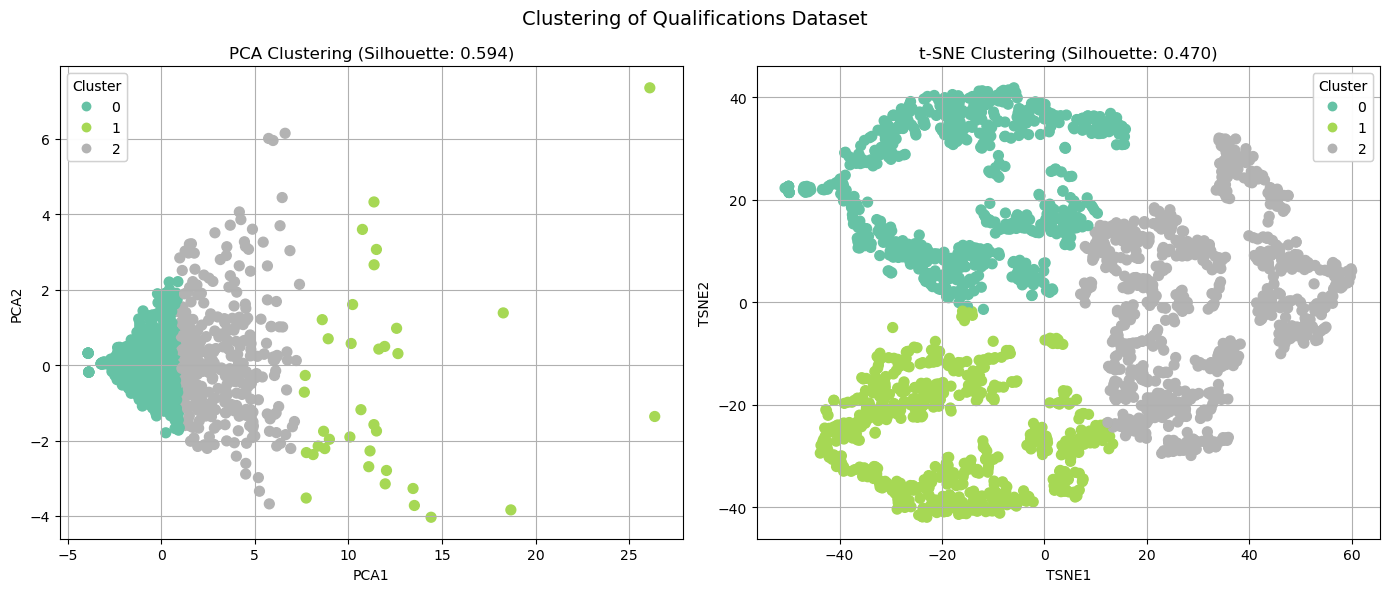

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

# Load the data
qual_df = pd.read_csv("qualifications_reduced.csv")

# Extract PCA and t-SNE features
X_pca = qual_df[["PCA1", "PCA2"]]
X_tsne = qual_df[["TSNE1", "TSNE2"]]

# KMeans Clustering
qual_df["PCA_Cluster"] = KMeans(n_clusters=3, random_state=42).fit_predict(X_pca)
qual_df["TSNE_Cluster"] = KMeans(n_clusters=3, random_state=42).fit_predict(X_tsne)

# Calculate Silhouette Scores
pca_score = silhouette_score(X_pca, qual_df["PCA_Cluster"])
tsne_score = silhouette_score(X_tsne, qual_df["TSNE_Cluster"])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA Plot
scatter_pca = axes[0].scatter(X_pca["PCA1"], X_pca["PCA2"], c=qual_df["PCA_Cluster"], cmap="Set2", s=50)
axes[0].set_title(f"PCA Clustering (Silhouette: {pca_score:.3f})")
axes[0].set_xlabel("PCA1")
axes[0].set_ylabel("PCA2")
axes[0].grid(True)
legend_pca = axes[0].legend(*scatter_pca.legend_elements(), title="Cluster")
axes[0].add_artist(legend_pca)

# t-SNE Plot
scatter_tsne = axes[1].scatter(X_tsne["TSNE1"], X_tsne["TSNE2"], c=qual_df["TSNE_Cluster"], cmap="Set2", s=50)
axes[1].set_title(f"t-SNE Clustering (Silhouette: {tsne_score:.3f})")
axes[1].set_xlabel("TSNE1")
axes[1].set_ylabel("TSNE2")
axes[1].grid(True)
legend_tsne = axes[1].legend(*scatter_tsne.legend_elements(), title="Cluster")
axes[1].add_artist(legend_tsne)

plt.suptitle("Clustering of Qualifications Dataset", fontsize=14)
plt.tight_layout()
plt.show()

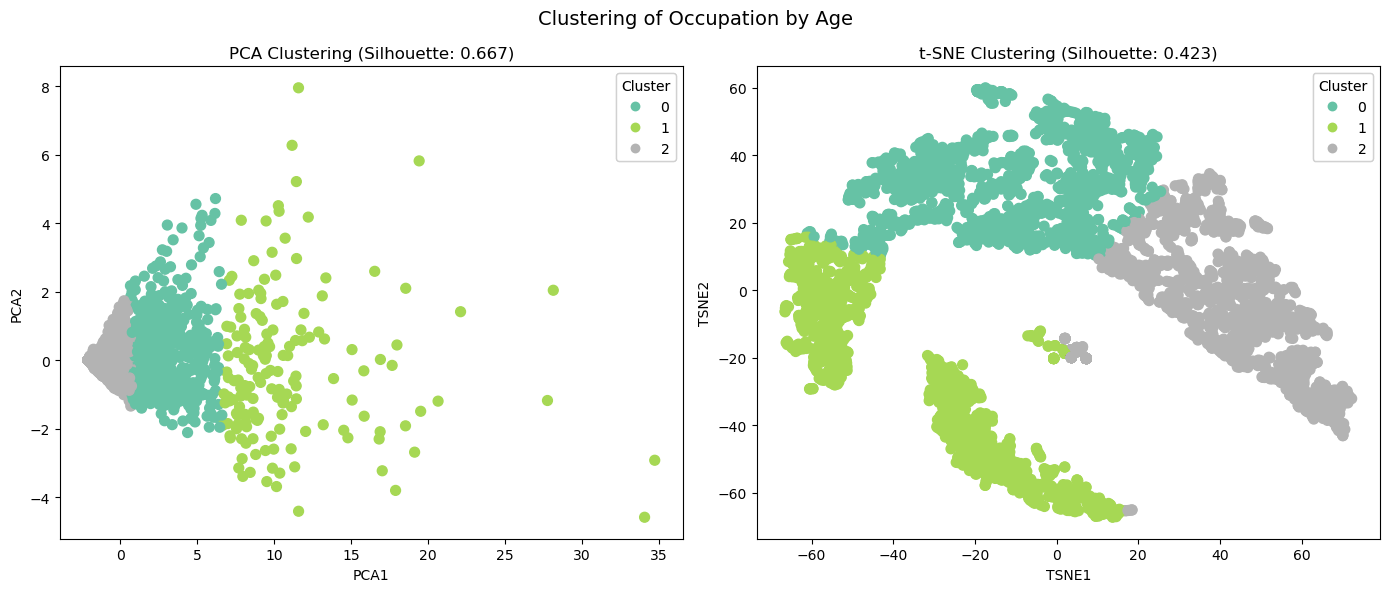

In [43]:
occupation_age_df = pd.read_csv("occupation_by_age_reduced.csv")
X_pca = occupation_age_df[["PCA1", "PCA2"]]
X_tsne = occupation_age_df[["TSNE1", "TSNE2"]]

occupation_age_df["PCA_Cluster"] = KMeans(n_clusters=3, random_state=42).fit_predict(X_pca)
occupation_age_df["TSNE_Cluster"] = KMeans(n_clusters=3, random_state=42).fit_predict(X_tsne)

pca_score = silhouette_score(X_pca, occupation_age_df["PCA_Cluster"])
tsne_score = silhouette_score(X_tsne, occupation_age_df["TSNE_Cluster"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter_pca = axes[0].scatter(X_pca["PCA1"], X_pca["PCA2"], c=occupation_age_df["PCA_Cluster"], cmap="Set2", s=50)
axes[0].set_title(f"PCA Clustering (Silhouette: {pca_score:.3f})")
axes[0].set_xlabel("PCA1")
axes[0].set_ylabel("PCA2")
legend_pca = axes[0].legend(*scatter_pca.legend_elements(), title="Cluster")
axes[0].add_artist(legend_pca)

scatter_tsne = axes[1].scatter(X_tsne["TSNE1"], X_tsne["TSNE2"], c=occupation_age_df["TSNE_Cluster"], cmap="Set2", s=50)
axes[1].set_title(f"t-SNE Clustering (Silhouette: {tsne_score:.3f})")
axes[1].set_xlabel("TSNE1")
axes[1].set_ylabel("TSNE2")
legend_tsne = axes[1].legend(*scatter_tsne.legend_elements(), title="Cluster")
axes[1].add_artist(legend_tsne)

plt.suptitle("Clustering of Occupation by Age", fontsize=14)
plt.tight_layout()
plt.show()

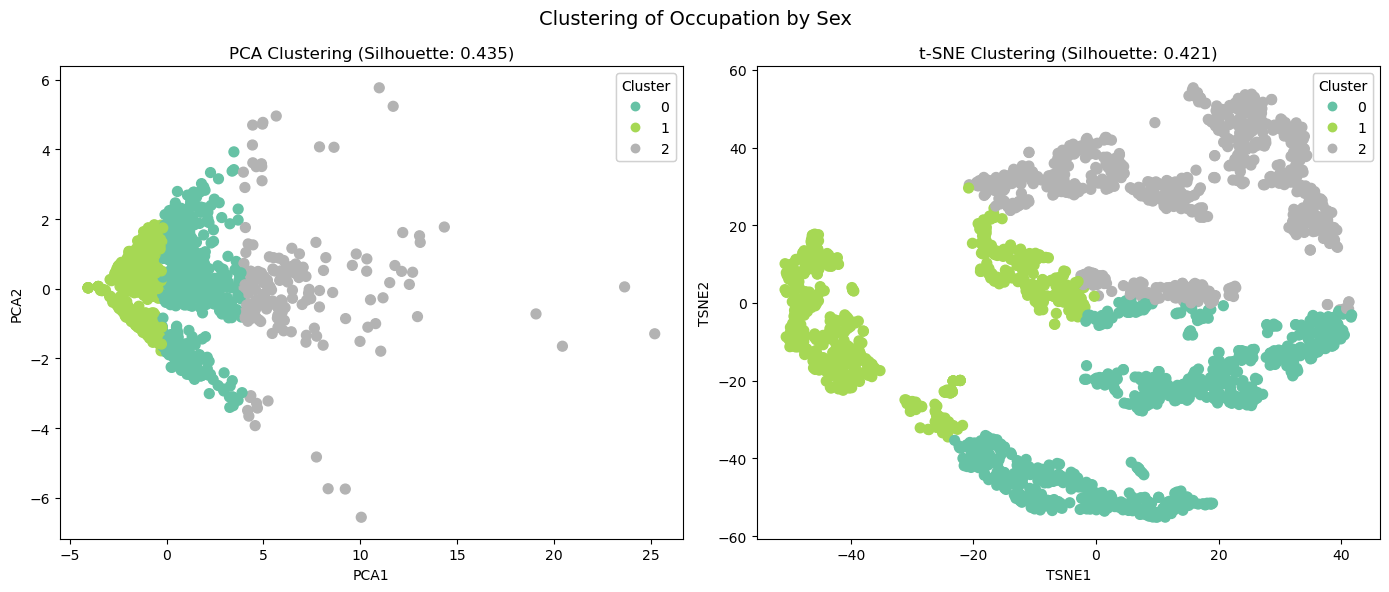

In [44]:
occupation_sex_df = pd.read_csv("occupation_by_sex_reduced.csv")
X_pca = occupation_sex_df[["PCA1", "PCA2"]]
X_tsne = occupation_sex_df[["TSNE1", "TSNE2"]]

occupation_sex_df["PCA_Cluster"] = KMeans(n_clusters=3, random_state=42).fit_predict(X_pca)
occupation_sex_df["TSNE_Cluster"] = KMeans(n_clusters=3, random_state=42).fit_predict(X_tsne)

pca_score = silhouette_score(X_pca, occupation_sex_df["PCA_Cluster"])
tsne_score = silhouette_score(X_tsne, occupation_sex_df["TSNE_Cluster"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter_pca = axes[0].scatter(X_pca["PCA1"], X_pca["PCA2"], c=occupation_sex_df["PCA_Cluster"], cmap="Set2", s=50)
axes[0].set_title(f"PCA Clustering (Silhouette: {pca_score:.3f})")
axes[0].set_xlabel("PCA1")
axes[0].set_ylabel("PCA2")
legend_pca = axes[0].legend(*scatter_pca.legend_elements(), title="Cluster")
axes[0].add_artist(legend_pca)

scatter_tsne = axes[1].scatter(X_tsne["TSNE1"], X_tsne["TSNE2"], c=occupation_sex_df["TSNE_Cluster"], cmap="Set2", s=50)
axes[1].set_title(f"t-SNE Clustering (Silhouette: {tsne_score:.3f})")
axes[1].set_xlabel("TSNE1")
axes[1].set_ylabel("TSNE2")
legend_tsne = axes[1].legend(*scatter_tsne.legend_elements(), title="Cluster")
axes[1].add_artist(legend_tsne)

plt.suptitle("Clustering of Occupation by Sex", fontsize=14)
plt.tight_layout()
plt.show()

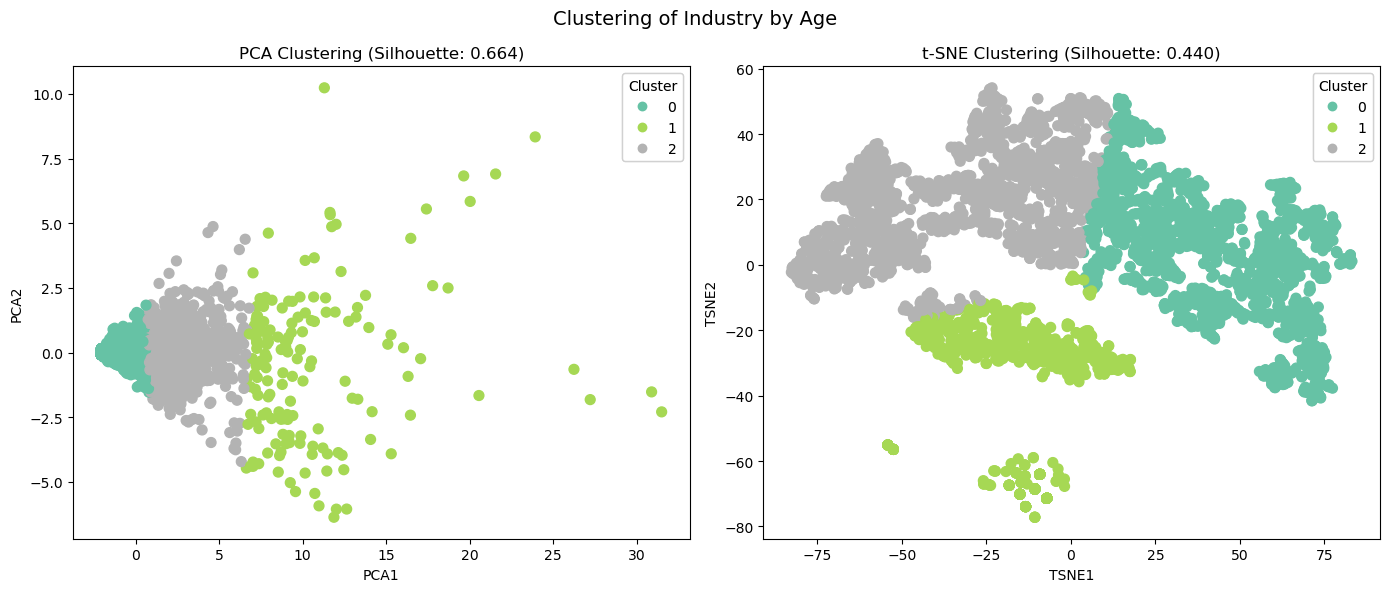

In [45]:
industry_age_df = pd.read_csv("industry_by_age_reduced.csv")
X_pca = industry_age_df[["PCA1", "PCA2"]]
X_tsne = industry_age_df[["TSNE1", "TSNE2"]]

industry_age_df["PCA_Cluster"] = KMeans(n_clusters=3, random_state=42).fit_predict(X_pca)
industry_age_df["TSNE_Cluster"] = KMeans(n_clusters=3, random_state=42).fit_predict(X_tsne)

pca_score = silhouette_score(X_pca, industry_age_df["PCA_Cluster"])
tsne_score = silhouette_score(X_tsne, industry_age_df["TSNE_Cluster"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter_pca = axes[0].scatter(X_pca["PCA1"], X_pca["PCA2"], c=industry_age_df["PCA_Cluster"], cmap="Set2", s=50)
axes[0].set_title(f"PCA Clustering (Silhouette: {pca_score:.3f})")
axes[0].set_xlabel("PCA1")
axes[0].set_ylabel("PCA2")
legend_pca = axes[0].legend(*scatter_pca.legend_elements(), title="Cluster")
axes[0].add_artist(legend_pca)

scatter_tsne = axes[1].scatter(X_tsne["TSNE1"], X_tsne["TSNE2"], c=industry_age_df["TSNE_Cluster"], cmap="Set2", s=50)
axes[1].set_title(f"t-SNE Clustering (Silhouette: {tsne_score:.3f})")
axes[1].set_xlabel("TSNE1")
axes[1].set_ylabel("TSNE2")
legend_tsne = axes[1].legend(*scatter_tsne.legend_elements(), title="Cluster")
axes[1].add_artist(legend_tsne)

plt.suptitle("Clustering of Industry by Age", fontsize=14)
plt.tight_layout()
plt.show()

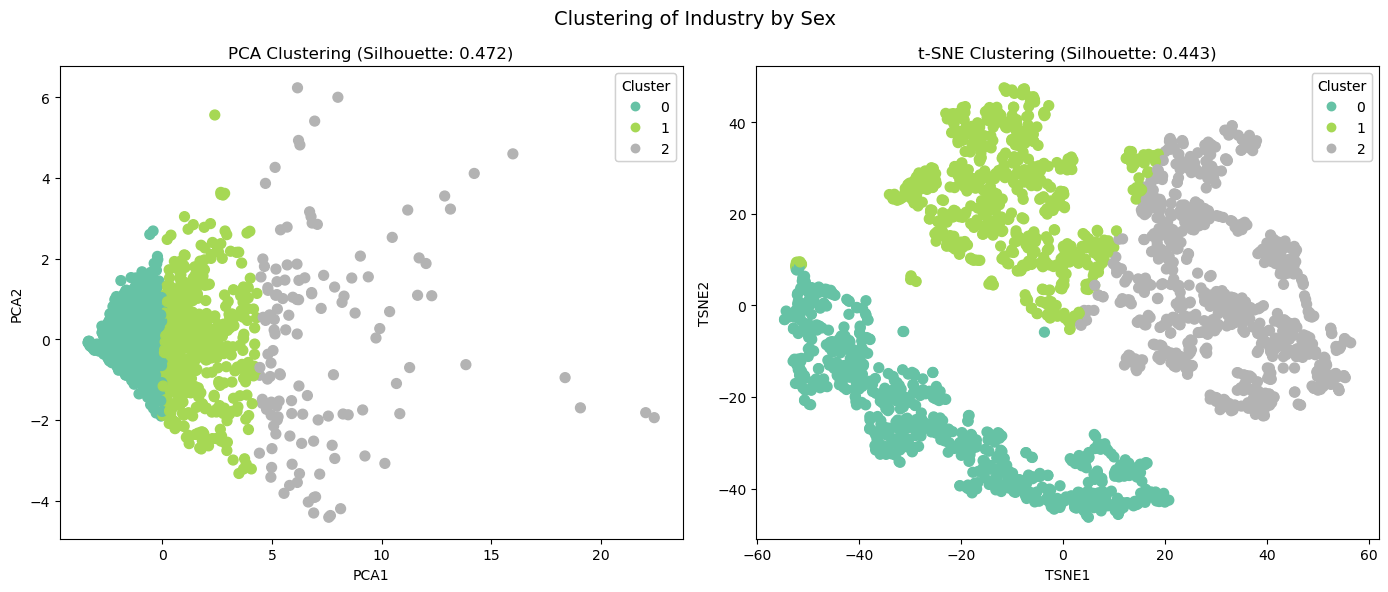

In [46]:
industry_sex_df = pd.read_csv("industry_by_sex_reduced.csv")
X_pca = industry_sex_df[["PCA1", "PCA2"]]
X_tsne = industry_sex_df[["TSNE1", "TSNE2"]]

industry_sex_df["PCA_Cluster"] = KMeans(n_clusters=3, random_state=42).fit_predict(X_pca)
industry_sex_df["TSNE_Cluster"] = KMeans(n_clusters=3, random_state=42).fit_predict(X_tsne)

pca_score = silhouette_score(X_pca, industry_sex_df["PCA_Cluster"])
tsne_score = silhouette_score(X_tsne, industry_sex_df["TSNE_Cluster"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter_pca = axes[0].scatter(X_pca["PCA1"], X_pca["PCA2"], c=industry_sex_df["PCA_Cluster"], cmap="Set2", s=50)
axes[0].set_title(f"PCA Clustering (Silhouette: {pca_score:.3f})")
axes[0].set_xlabel("PCA1")
axes[0].set_ylabel("PCA2")
legend_pca = axes[0].legend(*scatter_pca.legend_elements(), title="Cluster")
axes[0].add_artist(legend_pca)

scatter_tsne = axes[1].scatter(X_tsne["TSNE1"], X_tsne["TSNE2"], c=industry_sex_df["TSNE_Cluster"], cmap="Set2", s=50)
axes[1].set_title(f"t-SNE Clustering (Silhouette: {tsne_score:.3f})")
axes[1].set_xlabel("TSNE1")
axes[1].set_ylabel("TSNE2")
legend_tsne = axes[1].legend(*scatter_tsne.legend_elements(), title="Cluster")
axes[1].add_artist(legend_tsne)

plt.suptitle("Clustering of Industry by Sex", fontsize=14)
plt.tight_layout()
plt.show()

## Bayesian Forecasting

### Occupation

In [49]:
# Load and clean
df = pd.read_csv("occupation_by_age_cleaned.csv")

# Define occupation columns
occupation_cols = [
    "Managers, directors and senior officials",
    "Professional occupations",
    "Associate professional and technical occupations",
    "Administrative and secretarial occupations",
    "Skilled trades occupations",
    "Caring, leisure and other service occupations",
    "Sales and customer service occupations",
    "Process, plant and machine operatives",
    "Elementary occupations"
]

# Remove missing values
df = df.dropna(subset=occupation_cols)

# Aggregate by year
df_total = df.groupby("Year")[occupation_cols].sum().reset_index()
base_year = 2011
X_years = df_total["Year"].values
X_centered = X_years - base_year
future_years = np.array([2025, 2030])
future_centered = future_years - base_year

forecast_data = {}

for col in occupation_cols:
    y_values = df_total[col].values

    with pm.Model() as model:
        X_data = pm.Data("X_data", X_centered)
        y_data = pm.Data("y_data", y_values)

        # Smart priors based on direction of trend
        if y_values[1] > y_values[0]:  # upward trend
            beta_mu = 100_000
        else:  # downward trend
            beta_mu = -100_000

        alpha = pm.Normal("alpha", mu=np.mean(y_values), sigma=1_000_000)
        beta = pm.Normal("beta", mu=beta_mu, sigma=100_000)
        sigma = pm.HalfNormal("sigma", sigma=500_000)

        mu = alpha + beta * X_data
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

        trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=False)

    with model:
        posterior_predictive = pm.sample_posterior_predictive(trace, var_names=["alpha", "beta"], return_inferencedata=False)

    alpha_samples = posterior_predictive["alpha"]
    beta_samples = posterior_predictive["beta"]

    forecasts = []
    for year_offset in future_centered:
        preds = alpha_samples + beta_samples * year_offset
        forecasts.append(preds)

    forecast_data[col] = {
        "observed": y_values,
        "means": [np.mean(fs) for fs in forecasts],
        "lower": [np.percentile(fs, 2.5) for fs in forecasts],
        "upper": [np.percentile(fs, 97.5) for fs in forecasts],
    }

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 67 seconds.
There were 139 divergences after tuning. Increase `target_accept` or reparameterize.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [alpha, beta]


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


...

Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 47 seconds.
There were 160 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [alpha, beta]


Output()

C:\Users\snand\AppData\Local\Temp\ipykernel_15080\4139424305.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap("tab10", len(occupation_cols))


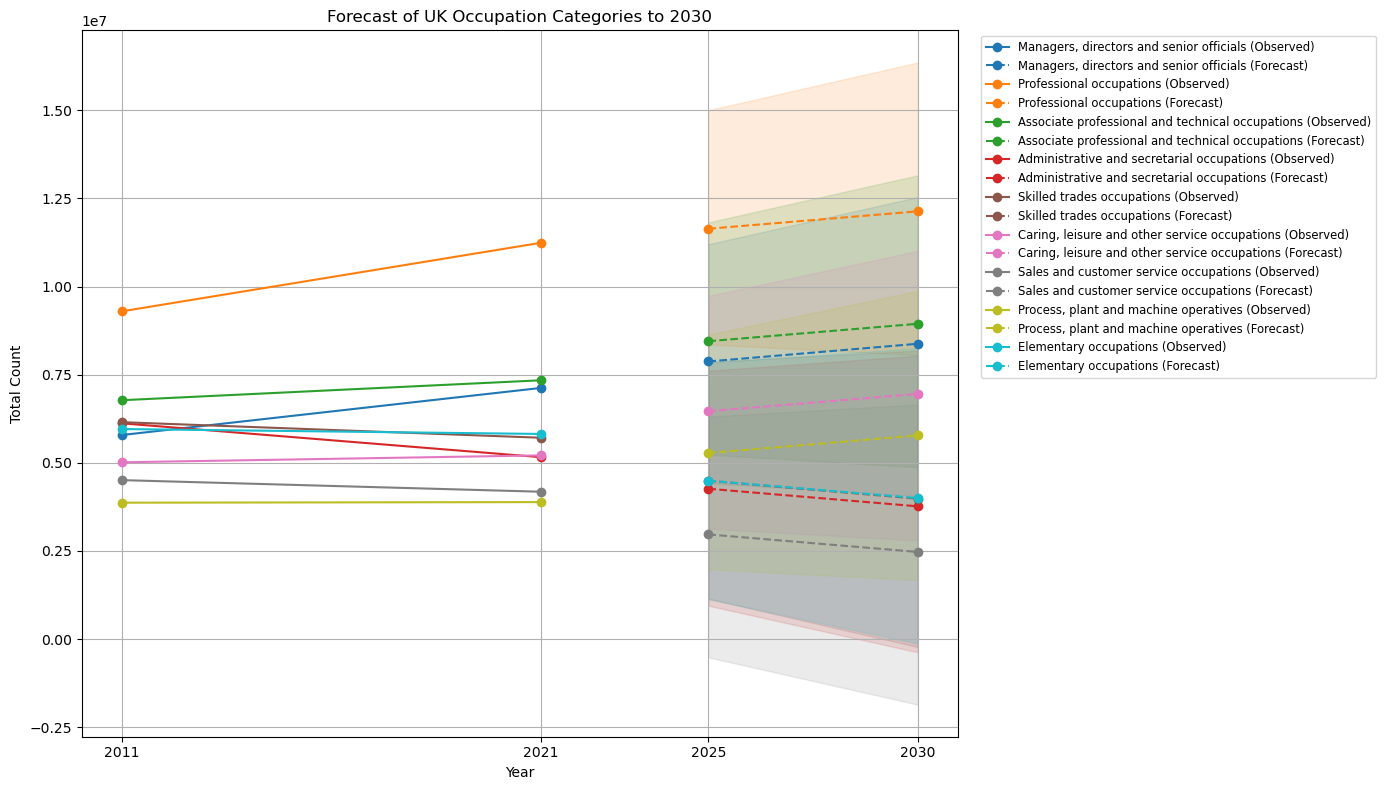

In [50]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Use a fixed color map
color_map = cm.get_cmap("tab10", len(occupation_cols))
colors = {col: color_map(i) for i, col in enumerate(occupation_cols)}

# Plot with matched colors
years_all = np.append(X_years, future_years)
plt.figure(figsize=(14, 8))

for col in occupation_cols:
    obs = forecast_data[col]["observed"]
    pred = forecast_data[col]["means"]
    lower = forecast_data[col]["lower"]
    upper = forecast_data[col]["upper"]

    plt.plot(X_years, obs, 'o-', label=f"{col} (Observed)", color=colors[col])
    plt.plot(future_years, pred, 'o--', label=f"{col} (Forecast)", color=colors[col])
    plt.fill_between(future_years, lower, upper, color=colors[col], alpha=0.15)

plt.title("Forecast of UK Occupation Categories to 2030")
plt.xlabel("Year")
plt.ylabel("Total Count")
plt.xticks(ticks=years_all.astype(int), labels=years_all.astype(int))
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()

#### *Forecast of UK Occupation Categories to 2030*
This chart presents Bayesian linear regression forecasts for nine major UK occupation categories, using data from 2011 and 2021. Each occupation was modeled independently using PyMC, with posterior sampling used to generate forecasts for 2025 and 2030. The shaded areas represent 95% credible intervals, offering insight into the uncertainty associated with each projection.

Key details:

* Solid lines represent observed data (2011 and 2021)

* Dashed lines represent forecasted means

* Credible intervals were calculated using posterior predictive sampling

* Distinct colors are used consistently for each occupation category

The graph highlights divergent trends across occupational groups, with continued growth in professional roles and declines in several manual or lower-skilled categories. This visual supports an understanding of how the occupational landscape may evolve over the coming decade.

### Qualification

In [53]:
# Load and clean
df = pd.read_csv("qualification_by_sex_cleaned.csv")

# Define qualification columns to forecast
qualification_cols = [
    "No qualifications",
    "Level 1 qualifications",
    "Level 2 qualifications",
    "Apprenticeship",
    "Level 3 qualifications",
    "Level 4 qualifications and above",
    "Other qualifications"
]

# Drop rows with missing qualification data
df = df.dropna(subset=qualification_cols)

# Aggregate by year
df_total = df.groupby("Year")[qualification_cols].sum().reset_index()
base_year = 2011
X_years = df_total["Year"].values
X_centered = X_years - base_year
future_years = np.array([2025, 2030])
future_centered = future_years - base_year

# Store forecasts
forecast_data = {}

for col in qualification_cols:
    y_values = df_total[col].values

    with pm.Model() as model:
        X_data = pm.Data("X_data", X_centered)
        y_data = pm.Data("y_data", y_values)

        # Priors based on observed direction
        beta_mu = 100_000 if y_values[1] > y_values[0] else -100_000

        alpha = pm.Normal("alpha", mu=np.mean(y_values), sigma=1_000_000)
        beta = pm.Normal("beta", mu=beta_mu, sigma=100_000)
        sigma = pm.HalfNormal("sigma", sigma=500_000)

        mu = alpha + beta * X_data
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

        trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=False)

    with model:
        posterior_predictive = pm.sample_posterior_predictive(trace, var_names=["alpha", "beta"], return_inferencedata=False)

    alpha_samples = posterior_predictive["alpha"]
    beta_samples = posterior_predictive["beta"]

    forecasts = []
    for year_offset in future_centered:
        preds = alpha_samples + beta_samples * year_offset
        forecasts.append(preds)

    forecast_data[col] = {
        "observed": y_values,
        "means": [np.mean(fs) for fs in forecasts],
        "lower": [np.percentile(fs, 2.5) for fs in forecasts],
        "upper": [np.percentile(fs, 97.5) for fs in forecasts],
    }

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.
There were 109 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [alpha, beta]


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


...

Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 41 seconds.
There were 202 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [alpha, beta]


Output()

C:\Users\snand\AppData\Local\Temp\ipykernel_15080\1863664512.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap("tab10", len(qualification_cols))


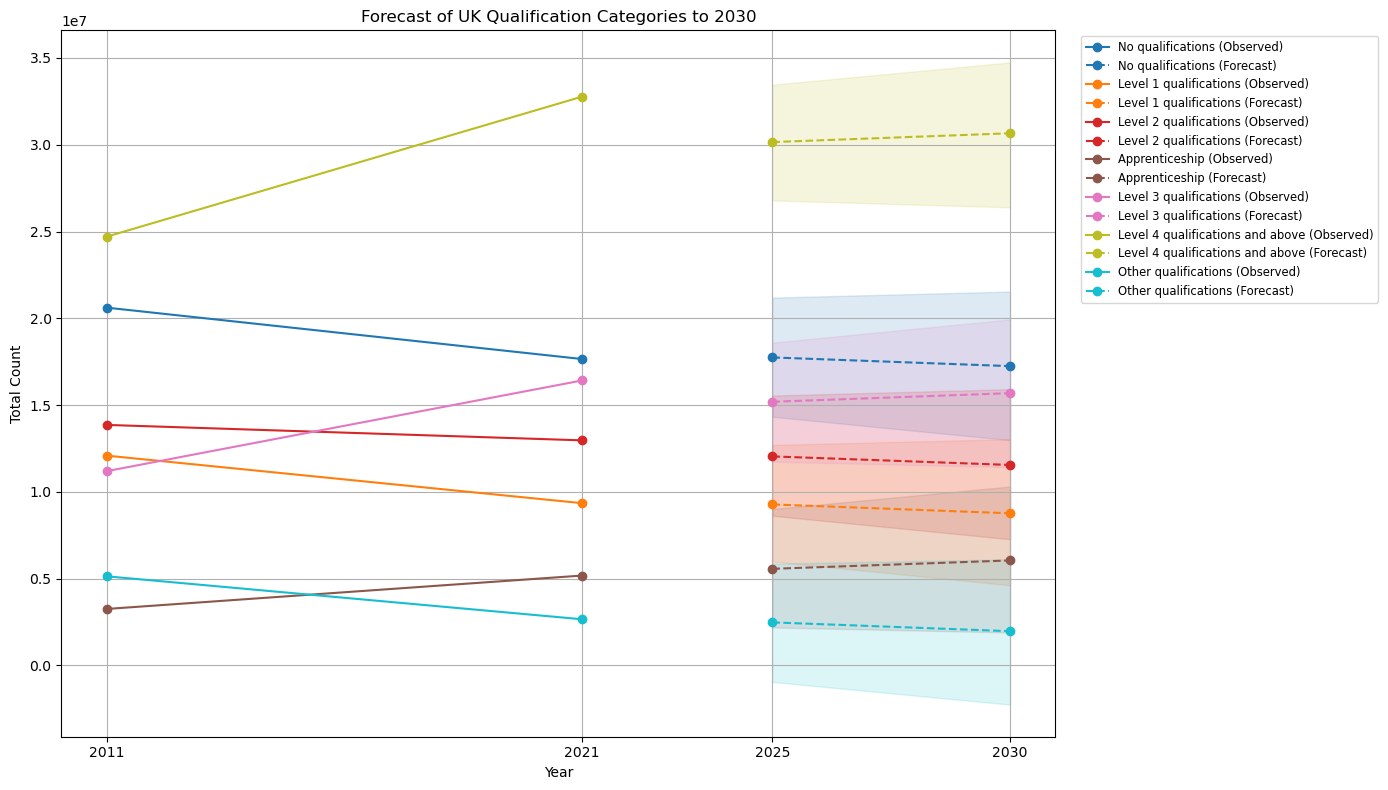

In [54]:
# Use a fixed color map
color_map = cm.get_cmap("tab10", len(qualification_cols))
colors = {col: color_map(i) for i, col in enumerate(qualification_cols)}

# Plot with matched colors
years_all = np.append(X_years, future_years)
plt.figure(figsize=(14, 8))

for col in qualification_cols:
    obs = forecast_data[col]["observed"]
    pred = forecast_data[col]["means"]
    lower = forecast_data[col]["lower"]
    upper = forecast_data[col]["upper"]

    plt.plot(X_years, obs, 'o-', label=f"{col} (Observed)", color=colors[col])
    plt.plot(future_years, pred, 'o--', label=f"{col} (Forecast)", color=colors[col])
    plt.fill_between(future_years, lower, upper, color=colors[col], alpha=0.15)

plt.title("Forecast of UK Qualification Categories to 2030")
plt.xlabel("Year")
plt.ylabel("Total Count")
plt.xticks(ticks=years_all.astype(int), labels=years_all.astype(int))
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()

#### *Forecast of UK Qualification Categories to 2030*
This visualization shows forecasts for educational attainment levels in the UK, covering seven qualification categories. Bayesian regression models were fitted to 2011 and 2021 census data, then used to project values for 2025 and 2030. Forecasts include 95% credible intervals to communicate model uncertainty.

Highlights:

* Forecasts were generated using posterior samples from PyMC models

* Observed and forecasted values are consistently color-matched

* Trends indicate a projected increase in higher-level qualifications (Level 4+) and a decline in lower-level and no qualifications

This forecast reveals a likely shift toward more highly educated populations by 2030, aligning with broader patterns of educational expansion and economic transformation.